# HiRiD AKI Trajectory Analysis

Acute Kidney Injury (AKI) trajectory modeling using HiRiD dataset.

Based on creatinine measurements to identify patients at risk for AKI progression.

## IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
import duckdb
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

# Import shared utilities
sys.path.insert(0, os.path.abspath('.'))
from notebook_utils import (
    aggregate_vitals_labs, drop_high_missing_columns, impute_features,
    plot_trajectory_distribution, plot_boxplots_with_stats,
    plot_roc_pr_curves, print_statistical_comparisons, train_repeated_cv, biomarker_summary_stats
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print("✓ Shared utilities loaded")

✓ Imports successful
✓ Shared utilities loaded


## SETUP

**First time setup**: Run the data loader to create the DuckDB database:

```bash
cd /home/gaga/data/physionet/HiRiD
python /home/gaga/tamarw1/trajectory-modeling/data/hirid/load_hirid_to_duckdb.py
```

## LOAD DATA

In [2]:
# Connect to HiRiD DuckDB
db_path = '/home/gaga/data/physionet/HiRiD/hirid.duckdb'
conn = duckdb.connect(db_path, read_only=True)

print(f"✓ Connected to HiRiD database: {db_path}")

✓ Connected to HiRiD database: /home/gaga/data/physionet/HiRiD/hirid.duckdb


In [3]:
# Check available tables
tables = conn.execute("SHOW TABLES").fetchdf()
print(f"\nAvailable tables ({len(tables)}):")
print(tables['name'].tolist())


Available tables (7):
['observations', 'patient_info', 'pharma_records', 'ref_general_table', 'ref_hirid_variable_reference', 'ref_ordinal_vars_ref', 'variable_metadata']


In [4]:
# Load patient cohort - optimized with subsampling first
# Step 1: Get a random sample of patient IDs first (much faster)
n_sample_patients = 20000  # Adjust this based on your needs

subsample_query = f"""
SELECT CAST(patientid AS INTEGER) as patientid
FROM ref_general_table
LIMIT {n_sample_patients}
"""

patient_ids_sample = conn.execute(subsample_query).fetchdf()['patientid'].tolist()

print(f"Step 1: Sampled {len(patient_ids_sample):,} patient IDs")

# Step 2: Now compute metrics only for these patients
patient_query = f"""
SELECT 
    CAST(g.patientid AS INTEGER) as patientid,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time,
    g.sex,
    CAST(g.age AS INTEGER) as age,
    g.discharge_status,
    COUNT(DISTINCT o.datetime) as n_observations,
    MIN(CAST(o.datetime AS TIMESTAMP)) as first_obs_time,
    MAX(CAST(o.datetime AS TIMESTAMP)) as last_obs_time,
    EPOCH(MAX(CAST(o.datetime AS TIMESTAMP)) - MIN(CAST(o.datetime AS TIMESTAMP))) / 86400.0 as los_days
FROM ref_general_table g
INNER JOIN observations o ON g.patientid = o.patientid
WHERE CAST(g.patientid AS INTEGER) IN {tuple(patient_ids_sample)}
GROUP BY g.patientid, g.admissiontime, g.sex, g.age, g.discharge_status
HAVING 
    EPOCH(MAX(CAST(o.datetime AS TIMESTAMP)) - MIN(CAST(o.datetime AS TIMESTAMP))) / 86400.0 >= 2.0  -- Minimum 2-day stay
    AND COUNT(DISTINCT o.datetime) >= 100  -- Sufficient data
"""

print(f"Step 2: Computing metrics for sampled patients...")
patient_df = conn.execute(patient_query).fetchdf()

print(f"\n✓ Loaded {len(patient_df):,} patients (after filtering)")
print(f"  Mean LOS: {patient_df['los_days'].mean():.1f} days")
print(f"  Mean observations: {patient_df['n_observations'].mean():.0f}")
print(f"  Mean age: {patient_df['age'].mean():.1f} years")

Step 1: Sampled 20,000 patient IDs
Step 2: Computing metrics for sampled patients...

✓ Loaded 5,414 patients (after filtering)
  Mean LOS: 6.1 days
  Mean observations: 26661
  Mean age: 62.1 years


In [5]:
# Sample subset for initial analysis
n_patients = min(5000, len(patient_df))
patient_subset = patient_df.sample(n_patients, random_state=920)['patientid'].tolist()

print(f"✓ Using {len(patient_subset):,} patients for analysis")

✓ Using 5,000 patients for analysis


In [6]:
# Find the correct variable ID for creatinine from the reference table
var_ref_query = """
SELECT *
FROM ref_hirid_variable_reference
WHERE LOWER("Variable Name") LIKE '%creat%'
"""

creatinine_vars = conn.execute(var_ref_query).fetchdf()
print("Creatinine-related variables:")
print(creatinine_vars[['ID', 'Variable Name', 'Unit']])

# Use blood creatinine (ID 20000600)
creat_var_id = '20000600'
print(f"\n✓ Using variable ID: {creat_var_id} (Creatinine [Moles/volume] in Blood)")

Creatinine-related variables:
         ID                                      Variable Name    Unit
0  24000210            Creatine kinase panel - Serum or Plasma     U/l
1  24000220  Creatine kinase.MB [Mass/volume] in Serum or P...     U/l
2  20000600                 Creatinine [Moles/volume] in Blood  umol/l
3  24000572                 Creatinine [Moles/volume] in Urine  umol/l
4  24000573                 Creatinine [Moles/volume] in Urine  umol/l

✓ Using variable ID: 20000600 (Creatinine [Moles/volume] in Blood)


In [7]:
# Load creatinine measurements using the correct variable ID (20000600 = blood creatinine)
creat_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    CAST(o.value AS DOUBLE) as creatinine,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time
FROM observations o
INNER JOIN ref_general_table g ON o.patientid = g.patientid
WHERE 
    o.variableid = '20000600'  -- Creatinine [Moles/volume] in Blood
    AND o.value IS NOT NULL
    AND CAST(o.value AS DOUBLE) > 0
    AND CAST(o.value AS DOUBLE) < 1000  -- Remove outliers (in µmol/L)
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

print("Loading creatinine measurements...")
creat_df = conn.execute(creat_query).fetchdf()

# Convert creatinine from µmol/L to mg/dL (HiRiD uses µmol/L)
creat_df['creatinine'] = creat_df['creatinine'] / 88.4

print(f"\n✓ Loaded {len(creat_df):,} creatinine measurements")
print(f"  Patients with creatinine: {creat_df['patientid'].nunique():,}")
if len(creat_df) > 0:
    print(f"  Mean creatinine: {creat_df['creatinine'].mean():.2f} mg/dL")
else:
    print("  ⚠️ No creatinine measurements found!")

Loading creatinine measurements...

✓ Loaded 72,373 creatinine measurements
  Patients with creatinine: 4,875
  Mean creatinine: 1.36 mg/dL


In [8]:
# Load vitals and labs - identify available variables from reference table
# Based on HiRiD variable reference, get IDs for key clinical variables

key_vars_query = """
SELECT DISTINCT
    CAST("ID" AS INTEGER) as variableid,
    "Variable Name" as variable_name,
    "Unit" as unit,
    "Source Table" as source_table
FROM ref_hirid_variable_reference
WHERE 
    -- Vitals
    "Variable Name" = 'Heart rate'
    OR "Variable Name" = 'Core body temperature'
    OR "Variable Name" = 'Invasive systolic arterial pressure'
    OR "Variable Name" = 'Invasive diastolic arterial pressure'
    OR "Variable Name" = 'Invasive mean arterial pressure'
    OR "Variable Name" = 'Non-invasive systolic arterial pressure'
    OR "Variable Name" = 'Non-invasive diastolic arterial pressure'
    OR "Variable Name" = 'Non-invasive mean arterial pressure'
    OR "Variable Name" = 'Respiratory rate'
    OR "Variable Name" = 'Peripheral oxygen saturation'
    -- Labs - Blood Chemistry
    OR "Variable Name" = 'Glucose [Moles/volume] in Serum or Plasma'
    OR "Variable Name" = 'Sodium [Moles/volume] in Blood'
    OR "Variable Name" = 'Potassium [Moles/volume] in Blood'
    OR "Variable Name" = 'Chloride [Moles/volume] in Blood'
    OR "Variable Name" = 'Bicarbonate [Moles/volume] in Arterial blood'
    OR "Variable Name" = 'Calcium.ionized [Moles/volume] in Blood'
    OR "Variable Name" = 'Magnesium [Moles/volume] in Blood'
    OR "Variable Name" = 'Phosphate [Moles/volume] in Blood'
    -- Labs - Renal
    OR "Variable Name" = 'Urea [Moles/volume] in Venous blood'
    OR "Variable Name" = 'Creatinine [Moles/volume] in Blood'
    -- Labs - Hematology
    OR "Variable Name" = 'Hemoglobin [Mass/volume] in Blood'
    OR "Variable Name" = 'Leukocytes [#/volume] in Blood'
    OR "Variable Name" = 'Platelets [#/volume] in Blood'
    -- Labs - Coagulation
    OR "Variable Name" = 'INR in Blood by Coagulation assay'
    OR "Variable Name" = 'aPTT in Blood by Coagulation assay'
    -- Labs - Liver/Metabolic
    OR "Variable Name" = 'Bilirubin.total [Moles/volume] in Serum or Plasma'
    OR "Variable Name" = 'Albumin [Mass/volume] in Serum or Plasma'
    -- Labs - Other
    OR "Variable Name" = 'Lactate [Mass/volume] in Arterial blood'
    -- Body measurements
    OR "Variable Name" = 'Body weight'
ORDER BY "Variable Name"
"""

key_vars = conn.execute(key_vars_query).fetchdf()
key_vars['unit'] = key_vars['unit'].fillna('N/A')
print(f"\n📊 Key clinical variables available in HiRiD:")
print(f"{'Variable ID':<12} {'Variable Name':<60} {'Unit':<15}")
print("="*100)
for _, row in key_vars.iterrows():
    print(f"{row['variableid']:<12} {row['variable_name']:<60} {row['unit']:<15}")

print(f"\n✓ Found {len(key_vars)} key clinical variables")

# Create variable ID to column name mapping (handle BP variants properly)
var_id_to_col = {}
for _, row in key_vars.iterrows():
    var_name = row['variable_name']
    var_id = str(row['variableid'])
    
    # Create concise column names, keeping BP types separate
    if 'Invasive systolic' in var_name:
        col_name = 'sbp_invasive'
    elif 'Invasive diastolic' in var_name:
        col_name = 'dbp_invasive'
    elif 'Invasive mean arterial' in var_name:
        col_name = 'mbp_invasive'
    elif 'Non-invasive systolic' in var_name:
        col_name = 'sbp_noninvasive'
    elif 'Non-invasive diastolic' in var_name:
        col_name = 'dbp_noninvasive'
    elif 'Non-invasive mean arterial' in var_name:
        col_name = 'mbp_noninvasive'
    elif 'Heart rate' in var_name:
        col_name = 'heart_rate'
    elif 'temperature' in var_name.lower():
        col_name = 'temperature'
    elif 'Respiratory rate' in var_name:
        col_name = 'respiratory_rate'
    elif 'oxygen saturation' in var_name.lower():
        col_name = 'spo2'
    elif 'Glucose' in var_name:
        col_name = 'glucose'
    elif 'Sodium' in var_name:
        col_name = 'sodium'
    elif 'Potassium' in var_name:
        col_name = 'potassium'
    elif 'Chloride' in var_name:
        col_name = 'chloride'
    elif 'Bicarbonate' in var_name:
        col_name = 'bicarbonate'
    elif 'Calcium' in var_name:
        col_name = 'calcium'
    elif 'Magnesium' in var_name:
        col_name = 'magnesium'
    elif 'Phosphate' in var_name:
        col_name = 'phosphate'
    elif 'Urea' in var_name:
        col_name = 'bun'
    elif 'Creatinine' in var_name:
        col_name = 'creatinine'
    elif 'Hemoglobin' in var_name:
        col_name = 'hemoglobin'
    elif 'Leukocytes' in var_name:
        col_name = 'wbc'
    elif 'Platelets' in var_name:
        col_name = 'platelets'
    elif 'INR' in var_name:
        col_name = 'inr'
    elif 'aPTT' in var_name:
        col_name = 'ptt'
    elif 'Bilirubin' in var_name:
        col_name = 'bilirubin'
    elif 'Albumin' in var_name:
        col_name = 'albumin'
    elif 'Lactate' in var_name:
        col_name = 'lactate'
    elif 'weight' in var_name.lower():
        col_name = 'weight'
    else:
        col_name = var_name.lower().replace(' ', '_')[:30]
    
    var_id_to_col[var_id] = col_name

print(f"\n📋 Variable mapping (ID → Column name):")
for var_id, col_name in sorted(var_id_to_col.items(), key=lambda x: x[1]):
    var_name = key_vars[key_vars['variableid'] == int(var_id)]['variable_name'].iloc[0]
    print(f"   {var_id:>10} → {col_name:25s} ({var_name})")

# Load observations for these variables from the patient subset
var_ids_str = "', '".join(var_id_to_col.keys())
obs_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    o.variableid,
    CAST(o.value AS DOUBLE) as value
FROM observations o
WHERE 
    o.variableid IN ('{var_ids_str}')
    AND o.value IS NOT NULL
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

print(f"\n⏳ Loading observations for {len(patient_subset):,} patients...")
obs_df = conn.execute(obs_query).fetchdf()

# Map variable IDs to column names
obs_df['variable'] = obs_df['variableid'].astype(str).map(var_id_to_col)

print(f"\n✓ Loaded {len(obs_df):,} observations")
print(f"  Unique patients: {obs_df['patientid'].nunique():,}")
print(f"  Unique variables: {obs_df['variable'].nunique()}")
print(f"  Time range: {obs_df['charttime'].min()} to {obs_df['charttime'].max()}")

# Show observation counts per variable
print(f"\n📊 Observations per variable:")
var_counts = obs_df.groupby('variable').size().sort_values(ascending=False)
for var_name, count in var_counts.items():
    print(f"   {var_name:25s}: {count:>10,} observations")


📊 Key clinical variables available in HiRiD:
Variable ID  Variable Name                                                Unit           
24000605     Albumin [Mass/volume] in Serum or Plasma                     g/L            
20004200     Bicarbonate [Moles/volume] in Arterial blood                 mmol/l         
20004300     Bilirubin.total [Moles/volume] in Serum or Plasma            umol/l         
10000400     Body weight                                                  kg             
24000522     Calcium.ionized [Moles/volume] in Blood                      mmol/l         
24000439     Chloride [Moles/volume] in Blood                             mmol/l         
24000521     Chloride [Moles/volume] in Blood                             mmol/l         
410          Core body temperature                                        °C             
20000600     Creatinine [Moles/volume] in Blood                           umol/l         
24000523     Glucose [Moles/volume] in Serum or Plasma

In [9]:
# convert creatinine in vitals_labs to mg/dl
obs_df.loc[obs_df['variable'] == 'creatinine', 'value'] = obs_df.loc[obs_df['variable'] == 'creatinine', 'value'] / 88.4

## PREPROCESS

In [10]:
# Calculate baseline creatinine (first 24h)
creat_df['charttime'] = pd.to_datetime(creat_df['charttime'])
creat_df['admission_time'] = pd.to_datetime(creat_df['admission_time'])

first_24h = creat_df[creat_df['charttime'] <= creat_df['admission_time'] + pd.Timedelta(hours=24)]

baseline_creat = first_24h.groupby('patientid')['creatinine'].first().reset_index()
baseline_creat.columns = ['patientid', 'baseline_creatinine']

print(f"\nBaseline Creatinine:")
print(f"   Patients with baseline: {len(baseline_creat):,}")
print(f"   Mean: {baseline_creat['baseline_creatinine'].mean():.2f} mg/dL")
print(f"   Median: {baseline_creat['baseline_creatinine'].median():.2f} mg/dL")


Baseline Creatinine:
   Patients with baseline: 4,474
   Mean: 1.25 mg/dL
   Median: 0.93 mg/dL


In [11]:
# Filter patients with sufficient measurements
creat_counts = creat_df.groupby('patientid').size()
valid_patients = creat_counts[creat_counts >= 5].index

creat_filtered = creat_df[creat_df['patientid'].isin(valid_patients)]
patient_final = patient_df[patient_df['patientid'].isin(valid_patients)].merge(
    baseline_creat, on='patientid', how='inner'
)

print(f"\nFiltering:")
print(f"   Patients with ≥5 creatinine measurements: {len(patient_final):,}")


Filtering:
   Patients with ≥5 creatinine measurements: 3,876


In [12]:
# Create time series with derived features
creat_ts = creat_filtered.merge(patient_final[['patientid', 'baseline_creatinine', 'admission_time']], 
                                 on=['patientid', 'admission_time'], how='left')

creat_ts['time_days'] = (creat_ts['charttime'] - creat_ts['admission_time']).dt.total_seconds() / 86400

# Create time_day (integer day)
creat_ts['time_day'] = creat_ts['time_days'].astype(int)
creat_ts = creat_ts.drop_duplicates(subset=['patientid', 'charttime'], keep='first')

print(f"\n✓ Time series created")
print(f"   Total measurements: {len(creat_ts):,}")
print(f"   Time range: {creat_ts['time_days'].min():.1f} to {creat_ts['time_days'].max():.1f} days")


✓ Time series created
   Total measurements: 26,060
   Time range: -0.0 to 28.0 days


In [14]:
# Save creatinine time series for trajectory computation script
output_path = '../../results/hirid/aki/creatinine_timeseries.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

creat_ts.to_csv(output_path, index=False)

print(f"\n✓ Saved creatinine time series: {output_path}")
print(f"   Shape: {creat_ts.shape}")
print(f"   Columns: {list(creat_ts.columns)}")


✓ Saved creatinine time series: ../../results/hirid/aki/creatinine_timeseries.csv
   Shape: (26244, 7)
   Columns: ['patientid', 'charttime', 'creatinine', 'admission_time', 'baseline_creatinine', 'time_days', 'time_day']


### AGGREGATE FEATURES

Aggregate vitals and labs into time windows for feature engineering

In [13]:
# Merge observations with patient admission times to calculate time_day
obs_df = obs_df.merge(
    patient_final[['patientid', 'admission_time']],
    on='patientid',
    how='inner'
)

obs_df['charttime'] = pd.to_datetime(obs_df['charttime'])
obs_df['admission_time'] = pd.to_datetime(obs_df['admission_time'])
obs_df['time_day'] = ((obs_df['charttime'] - obs_df['admission_time']).dt.total_seconds() / 86400).astype(int)

print(f"\n✓ Calculated time_day for observations")
print(f"  Time range: {obs_df['time_day'].min()} to {obs_df['time_day'].max()} days")

# Define valid ranges for each variable (clinically plausible values)
valid_ranges = {
    # Vitals
    'heart_rate': (20, 250),
    'temperature': (32, 42),
    'sbp_invasive': (40, 250),
    'dbp_invasive': (20, 180),
    'mbp_invasive': (30, 200),
    'sbp_noninvasive': (40, 250),
    'dbp_noninvasive': (20, 180),
    'mbp_noninvasive': (30, 200),
    'respiratory_rate': (4, 60),
    'spo2': (50, 100),
    
    # Labs - Chemistry
    'glucose': (20, 800),      # mg/dL (needs conversion from mmol/L)
    'sodium': (100, 180),      # mmol/L
    'potassium': (1.5, 10),    # mmol/L
    'chloride': (60, 140),     # mmol/L
    'bicarbonate': (5, 50),    # mmol/L
    'calcium': (0.5, 2.0),     # mmol/L (ionized)
    'magnesium': (0.3, 3.0),   # mmol/L
    'phosphate': (0.3, 4.0),   # mmol/L
    
    # Labs - Renal
    'bun': (0.5, 50),          # mmol/L (urea)
    'creatinine': (0.1, 15),  # mg/dL 
    
    # Labs - Hematology
    'hemoglobin': (40, 200),   # g/L
    'wbc': (0.1, 100),         # G/L (10^9/L)
    'platelets': (5, 1500),    # G/L (10^9/L)
    
    # Labs - Coagulation
    'inr': (0.5, 15),
    'ptt': (10, 300),          # seconds (aPTT)
    
    # Labs - Liver
    'bilirubin': (2, 800),     # µmol/L
    'albumin': (10, 60),       # g/L
    
    # Labs - Other
    'lactate': (0.2, 30),      # mmol/L
    'weight': (30, 300),       # kg
}

valid_ranges_df = pd.DataFrame.from_dict(valid_ranges, orient='index', columns=['min', 'max'])

print(f"\n📋 Defined valid ranges for {len(valid_ranges)} variables")

# Filter observations based on valid ranges
obs_df = obs_df.merge(
    valid_ranges_df.reset_index().rename(columns={'index': 'variable'}),
    on='variable',
    how='left'
)
obs_clean = obs_df[obs_df['value'].between(obs_df['min'], obs_df['max'])]

print(f"\n✓ Filtered observations")
print(f"  Before: {len(obs_df):,}")
print(f"  After:  {len(obs_clean):,}")
print(f"  Removed: {len(obs_df) - len(obs_clean):,} ({100*(len(obs_df)-len(obs_clean))/len(obs_df):.1f}%)")

# Aggregate vitals and labs by patient and time_day
# Calculate min, max, mean, std for each variable
print(f"\n⏳ Aggregating observations...")

vitals_labs_agg = obs_clean.pivot_table(
    index=['patientid', 'time_day'],
    columns='variable',
    values='value',
    aggfunc=['min', 'max', 'mean']
)

vitals_labs_agg.columns = [f"{var}_{stat}" for stat, var in vitals_labs_agg.columns]
# ffill imputation
vitals_labs_agg = vitals_labs_agg.sort_index().groupby(level=0).ffill()

vitals_labs_agg = vitals_labs_agg.reset_index()

print(f"\n✓ Aggregated vitals and labs")
print(f"  Shape: {vitals_labs_agg.shape}")
print(f"  Features: {vitals_labs_agg.shape[1] - 2 } (excluding patientid, time_day)")
print(f"  Unique patients: {vitals_labs_agg['patientid'].nunique():,}")
print(f"  Time windows: {len(vitals_labs_agg):,}")


# Drop features with >20% missing values after imputation
missing_pct = vitals_labs_agg.isna().mean()
cols_to_drop = (missing_pct[missing_pct > 0.2].index).tolist()

vitals_labs_clean = vitals_labs_agg.drop(columns=cols_to_drop)

print(f"\n✓ Dropped high-missingness columns (>20%)")
print(f"  Remaining features: {vitals_labs_clean.shape[1] - 2}")
print(f"  Dropped: {vitals_labs_agg.shape[1] - vitals_labs_clean.shape[1]} columns")

# Show which features were kept
feature_cols = [c for c in vitals_labs_clean.columns if c not in ['patientid', 'time_day']]
print(f"\n📊 Kept features ({len(feature_cols)}):")
for col in sorted(feature_cols):
    pct_missing = vitals_labs_clean[col].isna().mean()
    print(f"   {col:40s}: {pct_missing:3.2%} missing")


✓ Calculated time_day for observations
  Time range: 0 to 28 days

📋 Defined valid ranges for 29 variables

✓ Filtered observations
  Before: 129,146,191
  After:  115,046,514
  Removed: 14,099,677 (10.9%)

⏳ Aggregating observations...

✓ Aggregated vitals and labs
  Shape: (26862, 89)
  Features: 87 (excluding patientid, time_day)
  Unique patients: 3,876
  Time windows: 26,862

✓ Dropped high-missingness columns (>20%)
  Remaining features: 63
  Dropped: 24 columns

📊 Kept features (63):
   bicarbonate_max                         : 2.00% missing
   bicarbonate_mean                        : 2.00% missing
   bicarbonate_min                         : 2.00% missing
   bun_max                                 : 4.00% missing
   bun_mean                                : 4.00% missing
   bun_min                                 : 4.00% missing
   calcium_max                             : 2.14% missing
   calcium_mean                            : 2.14% missing
   calcium_min                 

In [14]:
patient_final = patient_final.merge(
    vitals_labs_clean,
    on='patientid',
    how='left'
)

patient_final.to_csv('../../results/hirid/aki/patient_features.csv', index=False)
print(f"\n✓ Saved patient features with vitals and labs: ../../results/hirid/aki/patient_features.csv")


✓ Saved patient features with vitals and labs: ../../results/hirid/aki/patient_features.csv


In [16]:
patient_final.columns

Index(['patientid', 'admission_time', 'sex', 'age', 'discharge_status',
       'n_observations', 'first_obs_time', 'last_obs_time', 'los_days',
       'baseline_creatinine', 'time_day', 'bicarbonate_min', 'bun_min',
       'calcium_min', 'chloride_min', 'creatinine_min', 'dbp_invasive_min',
       'heart_rate_min', 'hemoglobin_min', 'inr_min', 'lactate_min',
       'magnesium_min', 'mbp_invasive_min', 'phosphate_min', 'platelets_min',
       'potassium_min', 'respiratory_rate_min', 'sbp_invasive_min',
       'sodium_min', 'spo2_min', 'wbc_min', 'weight_min', 'bicarbonate_max',
       'bun_max', 'calcium_max', 'chloride_max', 'creatinine_max',
       'dbp_invasive_max', 'heart_rate_max', 'hemoglobin_max', 'inr_max',
       'lactate_max', 'magnesium_max', 'mbp_invasive_max', 'phosphate_max',
       'platelets_max', 'potassium_max', 'respiratory_rate_max',
       'sbp_invasive_max', 'sodium_max', 'spo2_max', 'wbc_max', 'weight_max',
       'bicarbonate_mean', 'bun_mean', 'calcium_mean', '

## TRAJECTORY MODELING

**Option 1**: Compute in this notebook (for quick testing)

**Option 2**: Run standalone script for SLURM (recommended for large cohorts):
```bash
python ../hirid_aki_trajs.py --window-days 7.0 --n-batches 10
```

In [15]:
# Load pre-computed trajectory probabilities (if using standalone script)
# OR compute in notebook (uncomment below)

# Option 1: Load from script output
trajectory_probs_path = '../../results/hirid/aki/aki_trajectory_probs_bayes.csv'

if os.path.exists(trajectory_probs_path):
    trajectory_probs = pd.read_csv(trajectory_probs_path)
    print(f"✓ Loaded trajectory probabilities from: {trajectory_probs_path}")
    print(f"   Shape: {trajectory_probs.shape}")
else:
    print(f"⚠️ File not found: {trajectory_probs_path}")
    print("   Run: python ../hirid_aki_trajs.py")

✓ Loaded trajectory probabilities from: ../../results/hirid/aki/aki_trajectory_probs_bayes.csv
   Shape: (8531, 8)



✓ Saved: creatinine_trajectory_distribution.png


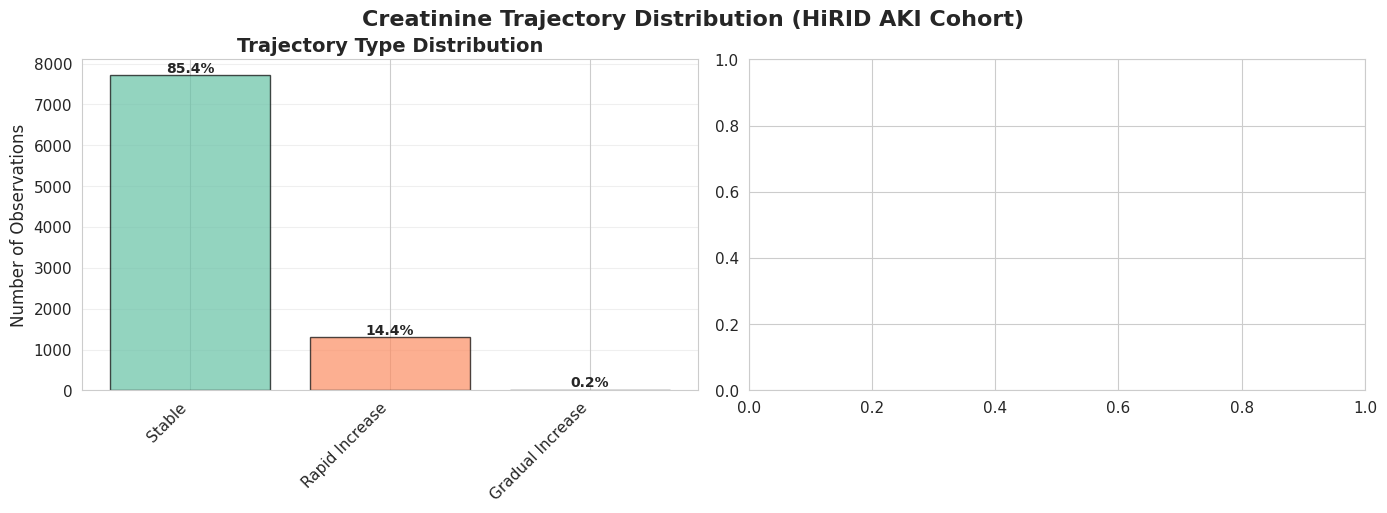

In [16]:
# Visualize trajectory distribution (using shared utility)
# Determine dominant trajectory
trajectory_probs['dominant_traj'] = trajectory_probs[[
    'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase'
]].idxmax(axis=1).str.replace('prob_', '')

# Merge with creatinine data for visualization
traj_with_creat = trajectory_probs.merge(
    creat_ts[['patientid', 'time_day', 'creatinine']],
    on=['patientid', 'time_day'],
    how='left'
)

fig, axes = plot_trajectory_distribution(
    df=traj_with_creat,
    traj_col='dominant_traj',
    biomarker_col='creatinine',
    biomarker_name='Creatinine (mg/dL)'
)
plt.suptitle('Creatinine Trajectory Distribution (HiRID AKI Cohort)', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../../results/hirid/aki/creatinine_trajectory_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: creatinine_trajectory_distribution.png")
plt.show()

## SUMMARY STATISTICS

Generate creatinine summary statistics (matching MIMIC's approach)

In [17]:
creat_ts = creat_ts.drop_duplicates(subset=['patientid', 'charttime'])

In [18]:
# Generate creatinine summary statistics (matching MIMIC's approach)
LOOKBACK_DAYS = 7

creat_summary_7d = biomarker_summary_stats(creat_ts, 'creatinine', LOOKBACK_DAYS)

print(f"✓ Generated creatinine summary stats: {len(creat_summary_7d):,} timepoints")
print(f"  Features: {list(creat_summary_7d.columns)}")
print(f"  Unique patients: {creat_summary_7d['patientid'].nunique():,}")

# Show sample statistics
print(f"\n📊 Sample Summary Statistics (first patient):")
sample_patient = creat_summary_7d['patientid'].iloc[0]
sample_data = creat_summary_7d[creat_summary_7d['patientid'] == sample_patient].head(3)
print(sample_data.to_string(index=False))

# Save summary stats
os.makedirs('../../results/hirid/aki', exist_ok=True)
creat_summary_7d.to_csv('../../results/hirid/aki/creatinine_summary_7d.csv', index=False)
print(f"\n✓ Saved: results/hirid/aki/creatinine_summary_7d.csv")

✓ Generated creatinine summary stats: 23,911 timepoints
  Features: ['patientid', 'time_day', 'creatinine_mean_7d', 'creatinine_max_7d', 'creatinine_min_7d', 'creatinine_change_7d', 'creatinine_linear_trend_7d', 'creatinine_std_7d']
  Unique patients: 4,100

📊 Sample Summary Statistics (first patient):
 patientid  time_day  creatinine_mean_7d  creatinine_max_7d  creatinine_min_7d  creatinine_change_7d  creatinine_linear_trend_7d  creatinine_std_7d
         2         0            0.927602           0.927602           0.927602              0.000000                         NaN                NaN
         2         1            0.910633           0.927602           0.893665             -0.033937                   -0.033937           0.023997
         2         2            0.882353           0.927602           0.825792             -0.101810                   -0.050905           0.051839

✓ Saved: results/hirid/aki/creatinine_summary_7d.csv


## PREPARE FOR MODELS

Define feature sets and prepare data for modeling

In [19]:
# Configuration - same as MIMIC
PREDICTION_GAP_DAYS = 1.0      # Don't predict events within 24h (too immediate for intervention)
PREDICTION_WINDOW_DAYS = 4.0   # Predict AKI Stage 3 within 4 days after gap

print(f"📋 Prediction Configuration:")
print(f"   Gap:    {PREDICTION_GAP_DAYS} days (exclusion period)")
print(f"   Window: {PREDICTION_WINDOW_DAYS} days (prediction horizon)")
print(f"   Total:  {PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS} days lookahead")

# Note: HiRiD doesn't have dialysis data readily available
# We'll define AKI Stage 3 based on creatinine criteria only

aki_events = []
excluded_counts = {'already_aki': 0, 'no_future_data': 0}


for patientid, grp in patient_final.groupby('patientid'):
    grp = grp.sort_values('time_day')
    baseline = grp['baseline_creatinine'].iloc[0] 
    
    for i in range(len(grp)):
        current_time = grp.iloc[i]['time_day']
        current_creat = grp.iloc[i]['creatinine_mean']
        
        # Skip if already in AKI Stage 3 (prevalent cases)
        if current_creat >= 3 * baseline or current_creat >= 4.0:
            excluded_counts['already_aki'] += 1
            continue
        
        # Define prediction window (with gap)
        prediction_start = current_time + PREDICTION_GAP_DAYS + 1
        prediction_end = current_time + PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS + 1
        
        future_window = creat_ts[(creat_ts['patientid'] == patientid) &
                                  (creat_ts['time_days'].between(prediction_start, prediction_end, inclusive='both'))]
        
        if len(future_window) == 0:
            excluded_counts['no_future_data'] += 1
            continue
        
        # Check AKI Stage 3 criteria in prediction window
        aki_stage3_creat = (
            (future_window['creatinine'] >= 3 * baseline).any() |
            ((future_window['creatinine'] >= 4.0) & 
             (future_window['creatinine'] - current_creat >= 0.5)).any()
        )
        
        target_aki = int(aki_stage3_creat)
        
        aki_events.append({
            'patientid': patientid,
            'time_day': current_time,
            'target_aki_stage3': target_aki,
            'current_creatinine': current_creat,
            'baseline_creatinine': baseline,
            'creat_fold_change': current_creat / baseline,
            'prediction_gap_days': PREDICTION_GAP_DAYS,
            'prediction_window_days': PREDICTION_WINDOW_DAYS
        })

aki_outcomes_df = pd.DataFrame(aki_events)

# CRITICAL: For each patient, keep all negative windows but only the FIRST positive event
# This ensures we predict the first occurrence of aki Stage 3
aki_outcome_df = aki_outcomes_df.sort_values(['patientid', 'time_day'])
positive_first = aki_outcome_df[aki_outcome_df['target_aki_stage3'] == 1].groupby('patientid').first().reset_index()
all_negatives = aki_outcome_df[aki_outcome_df['target_aki_stage3'] == 0]
aki_outcome_df = pd.concat([all_negatives, positive_first], ignore_index=True).sort_values(['patientid', 'time_day']).reset_index(drop=True)

print(f"\n📊 Outcome Definition Summary:")
print(f"   Total prediction windows: {len(aki_outcomes_df):,}")
print(f"   Unique patients: {aki_outcomes_df['patientid'].nunique():,}")
print(f"   Windows per patient: {aki_outcomes_df.groupby('patientid').size().mean():.1f}")

print(f"\n   Exclusions:")
print(f"      Already in AKI Stage 3: {excluded_counts['already_aki']:,}")
print(f"      No future data: {excluded_counts['no_future_data']:,}")

print(f"\n   AKI Stage 3 Events ({PREDICTION_GAP_DAYS}+{PREDICTION_WINDOW_DAYS} days):")
print(f"      Total events: {aki_outcomes_df['target_aki_stage3'].sum():,}")
print(f"      Event rate: {100*aki_outcomes_df['target_aki_stage3'].mean():.1f}%")

# Validation checks
print(f"\n🔍 Validation:")
if aki_outcomes_df['target_aki_stage3'].mean() < 0.01:
    print(f"   ⚠️  Event rate very low (<1%)")
elif aki_outcomes_df['target_aki_stage3'].mean() > 0.15:
    print(f"   ⚠️  Event rate high (>15%)")
else:
    print(f"   ✓ Event rate reasonable for predictive modeling")

📋 Prediction Configuration:
   Gap:    1.0 days (exclusion period)
   Window: 4.0 days (prediction horizon)
   Total:  5.0 days lookahead

📊 Outcome Definition Summary:
   Total prediction windows: 16,084
   Unique patients: 3,352
   Windows per patient: 4.8

   Exclusions:
      Already in AKI Stage 3: 905
      No future data: 9,873

   AKI Stage 3 Events (1.0+4.0 days):
      Total events: 456
      Event rate: 2.8%

🔍 Validation:
   ✓ Event rate reasonable for predictive modeling


In [19]:
aki_outcomes_df.columns

Index(['patientid', 'time_day', 'target_aki_stage3', 'current_creatinine',
       'baseline_creatinine', 'creat_fold_change', 'prediction_gap_days',
       'prediction_window_days'],
      dtype='object')

In [20]:
patient_final.columns

Index(['patientid', 'admission_time', 'sex', 'age', 'discharge_status',
       'n_observations', 'first_obs_time', 'last_obs_time', 'los_days',
       'baseline_creatinine', 'time_day', 'bicarbonate_min', 'bun_min',
       'calcium_min', 'chloride_min', 'creatinine_min', 'dbp_invasive_min',
       'heart_rate_min', 'hemoglobin_min', 'inr_min', 'lactate_min',
       'magnesium_min', 'mbp_invasive_min', 'phosphate_min', 'platelets_min',
       'potassium_min', 'respiratory_rate_min', 'sbp_invasive_min',
       'sodium_min', 'spo2_min', 'wbc_min', 'weight_min', 'bicarbonate_max',
       'bun_max', 'calcium_max', 'chloride_max', 'creatinine_max',
       'dbp_invasive_max', 'heart_rate_max', 'hemoglobin_max', 'inr_max',
       'lactate_max', 'magnesium_max', 'mbp_invasive_max', 'phosphate_max',
       'platelets_max', 'potassium_max', 'respiratory_rate_max',
       'sbp_invasive_max', 'sodium_max', 'spo2_max', 'wbc_max', 'weight_max',
       'bicarbonate_mean', 'bun_mean', 'calcium_mean', '

In [19]:
trajectory_probs.columns

Index(['patientid', 'time_days', 'time_day', 'creatinine',
       'baseline_creatinine', 'prob_stable', 'prob_gradual_increase',
       'prob_rapid_increase'],
      dtype='object')

In [20]:
# Merge trajectory probabilities and summary stats
prediction_dataset = aki_outcomes_df.merge(
    trajectory_probs[[
        'patientid', 'time_day', 
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase'
    ]],
    on=['patientid', 'time_day'],
    how='left'
)

# Add summary statistics
prediction_dataset = prediction_dataset.merge(
    creat_summary_7d.fillna(0),
    on=['patientid', 'time_day'],
    how='left'
)

# Add derived trajectory feature
prediction_dataset['prob_worsening'] = (
    prediction_dataset['prob_gradual_increase'] + 
    prediction_dataset['prob_rapid_increase']
)

# Merge patient demographics
patient_static = patient_final[['patientid', 'age', 'sex']].drop_duplicates()
prediction_dataset = prediction_dataset.merge(
    patient_static,
    on='patientid',
    how='left'
)

# Define vitals/labs features list
vitals_labs_features = ['bicarbonate_min', 'bun_min',
       'calcium_min', 'chloride_min', 'creatinine_min', 'dbp_invasive_min',
       'heart_rate_min', 'hemoglobin_min', 'inr_min', 'lactate_min',
       'magnesium_min', 'mbp_invasive_min', 'phosphate_min', 'platelets_min',
       'potassium_min', 'respiratory_rate_min', 'sbp_invasive_min',
       'sodium_min', 'spo2_min', 'wbc_min', 'bicarbonate_max',
       'bun_max', 'calcium_max', 'chloride_max', 'creatinine_max',
       'dbp_invasive_max', 'heart_rate_max', 'hemoglobin_max', 'inr_max',
       'lactate_max', 'magnesium_max', 'mbp_invasive_max', 'phosphate_max',
       'platelets_max', 'potassium_max', 'respiratory_rate_max',
       'sbp_invasive_max', 'sodium_max', 'spo2_max', 'wbc_max',
       'bicarbonate_mean', 'bun_mean', 'calcium_mean', 'chloride_mean',
       'creatinine_mean', 'dbp_invasive_mean', 'heart_rate_mean',
       'hemoglobin_mean', 'inr_mean', 'lactate_mean', 'magnesium_mean',
       'mbp_invasive_mean', 'phosphate_mean', 'platelets_mean',
       'potassium_mean', 'respiratory_rate_mean', 'sbp_invasive_mean',
       'sodium_mean', 'spo2_mean', 'wbc_mean', 'weight_mean']

# Merge vitals and labs features
prediction_dataset = prediction_dataset.merge(
    patient_final[vitals_labs_features + ['patientid', 'time_day']].drop_duplicates(subset=['patientid', 'time_day']),
    on=['patientid', 'time_day'], 
    how='left'
)

# Backfill weight only
prediction_dataset['weight_mean'] = prediction_dataset.groupby('patientid')['weight_mean'].bfill()

# Add creatinine-derived features
prediction_dataset['creat_above_normal'] = (prediction_dataset['current_creatinine'] > 1.2).astype(int)

print(f"\n📋 Final Prediction Dataset:")
print(f"   Rows: {len(prediction_dataset):,}")
print(f"   Columns: {len(prediction_dataset.columns)}")
print(f"   Unique patients: {prediction_dataset['patientid'].nunique():,}")

# Save
os.makedirs('../../results/hirid/aki', exist_ok=True)
prediction_dataset.to_csv('../../results/hirid/aki/aki_prediction_dataset.csv', index=False)
print(f"\n✓ Saved: results/hirid/aki/aki_prediction_dataset.csv")


📋 Final Prediction Dataset:
   Rows: 16,084
   Columns: 82
   Unique patients: 3,352

✓ Saved: results/hirid/aki/aki_prediction_dataset.csv


In [21]:
# Get summary stat column names
summary_stat_cols = [col for col in creat_summary_7d.columns if col not in ['patientid', 'time_day']]

# Define feature sets (matching MIMIC's structure)
feature_sets = {
    'Trajectory Only': [
        'prob_stable',
        'prob_gradual_increase',
        'prob_rapid_increase',
        'prob_worsening'
    ],
    
    'Summary Stats Only': summary_stat_cols,
    
    'Trajectory + Summary Stats': [
        # Trajectory
        'prob_stable',
        'prob_gradual_increase',
        'prob_rapid_increase',
        'prob_worsening'
    ] + summary_stat_cols,
    
    'Static Only': [
        # Creatinine
        'creat_fold_change',
        'creat_above_normal',
        'baseline_creatinine',
        'current_creatinine',
        
        # Demographics
        'age', 'sex'
    ],
    
    'Trajectory + Static': [
        # Trajectory
        'prob_stable',
        'prob_gradual_increase',
        'prob_rapid_increase',
        'prob_worsening',
        
        # Creatinine
        'baseline_creatinine',
        'creat_fold_change',
        'creat_above_normal',
        'current_creatinine',
        
        # Demographics
        'age', 'sex'
    ],
    
    'Summary Stats + Static': summary_stat_cols + [
        # Creatinine
        'creat_fold_change',
        'creat_above_normal',
        'baseline_creatinine',
        'current_creatinine',
        
        # Demographics
        'age', 'sex'
    ],
    
    'Trajectory + Summary Stats + Static': [
        # Trajectory
        'prob_stable',
        'prob_gradual_increase',
        'prob_rapid_increase',
        'prob_worsening'
    ] + summary_stat_cols + [
        # Creatinine
        'baseline_creatinine',
        'creat_fold_change',
        'creat_above_normal',
        'current_creatinine',
        
        # Demographics
        'age', 'sex'
    ],

    'Static + Dynamic': [
        # Creatinine
        'creat_fold_change',
        'creat_above_normal',
        'baseline_creatinine',
        
        # Demographics
        'age', 'sex'
    ] + vitals_labs_features,
    
    'Trajectory + Static + Dynamic': [
        # Trajectory
        'prob_stable',
        'prob_gradual_increase',
        'prob_rapid_increase',
        'prob_worsening',
        
        # Creatinine
        'baseline_creatinine',
        'creat_fold_change',
        'creat_above_normal',
        
        # Demographics
        'age', 'sex'
    ] + vitals_labs_features,
    
    'Summary Stats + Static + Dynamic': summary_stat_cols + [
        # Creatinine
        'creat_fold_change',
        'creat_above_normal',
        'baseline_creatinine',
        
        # Demographics
        'age', 'sex'
    ] + vitals_labs_features,
    
    'Trajectory + Summary Stats + Static + Dynamic': [
        # Trajectory
        'prob_stable',
        'prob_gradual_increase',
        'prob_rapid_increase',
        'prob_worsening'
    ] + summary_stat_cols + [
        # Creatinine
        'baseline_creatinine',
        'creat_fold_change',
        'creat_above_normal',
        
        # Demographics
        'age', 'sex'
    ] + vitals_labs_features
}

print(f"📋 Feature Set Summary:")
for name, features in feature_sets.items():
    print(f"   {name:50s}: {len(features):2d} features")

📋 Feature Set Summary:
   Trajectory Only                                   :  4 features
   Summary Stats Only                                :  6 features
   Trajectory + Summary Stats                        : 10 features
   Static Only                                       :  6 features
   Trajectory + Static                               : 10 features
   Summary Stats + Static                            : 12 features
   Trajectory + Summary Stats + Static               : 16 features
   Static + Dynamic                                  : 66 features
   Trajectory + Static + Dynamic                     : 70 features
   Summary Stats + Static + Dynamic                  : 72 features
   Trajectory + Summary Stats + Static + Dynamic     : 76 features


In [22]:
# Prepare data for modeling
prediction_clean = prediction_dataset.dropna(subset=['target_aki_stage3'])

# Encode gender
if 'sex' in prediction_clean.columns:
    prediction_clean['sex'] = prediction_clean['sex'].map({'M': 1, 'F': 0})

# Intelligent imputation strategy (matching MIMIC's approach)
print(f"\n🔧 Applying intelligent imputation strategy:")

# 1. Trajectory probabilities: forward fill within patient with limit
traj_cols = ['prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening']
for col in traj_cols:
    if col in prediction_clean.columns:
        # Forward fill up to 2 time windows
        prediction_clean[col] = prediction_clean.groupby('patientid')[col].fillna(method='ffill', limit=2)
        # Remaining NaN values set to 0
        prediction_clean[col] = prediction_clean[col].fillna(0)
print(f"   ✓ Trajectory probs: ffill limit=2, then 0")


# 4. Current creatinine: forward fill with limit
if 'current_creatinine' in prediction_clean.columns:
    prediction_clean['current_creatinine'] = prediction_clean.groupby('patientid')['current_creatinine'].fillna(method='ffill', limit=2)
print(f"   ✓ Current creatinine: ffill limit=2")

# 5. Recalculate derived features after imputation
prediction_clean['creat_above_normal'] = (prediction_clean['current_creatinine'] > 1.2).fillna(0).astype(int)

y = prediction_clean['target_aki_stage3']
groups = prediction_clean['patientid']

print(f"\n📋 Dataset for Modeling:")
print(f"   Total samples: {len(y):,}")
print(f"   Positive class: {y.sum():,} ({y.mean():.1%})")
print(f"   Unique patients: {groups.nunique():,}")
print(f"   Avg windows/patient: {len(y) / groups.nunique():.1f}")
print(f"\n📊 Missingness after imputation:")
print(f"   Overall missing rate: {prediction_clean.drop(columns=['patientid', 'target_aki_stage3']).isna().mean().mean():.2%}")

# Show features with highest missingness
missing_rates = prediction_clean.drop(columns=['patientid', 'target_aki_stage3']).isna().mean().sort_values(ascending=False)
high_missing = missing_rates[missing_rates > 0.1].head(10)
if len(high_missing) > 0:
    print(f"\n   Features with >10% missing:")
    for feat, rate in high_missing.items():
        print(f"      {feat:40s}: {rate:.1%}")


🔧 Applying intelligent imputation strategy:
   ✓ Trajectory probs: ffill limit=2, then 0
   ✓ Current creatinine: ffill limit=2

📋 Dataset for Modeling:
   Total samples: 16,084
   Positive class: 456 (2.8%)
   Unique patients: 3,352
   Avg windows/patient: 4.8

📊 Missingness after imputation:
   Overall missing rate: 2.32%

   Features with >10% missing:
      inr_max                                 : 12.7%
      inr_mean                                : 12.7%
      inr_min                                 : 12.7%


## EVALUATE

Train models with repeated cross-validation and compare performance

In [23]:
# Repeated Cross-validation with statistical robustness
n_repeats = 10
n_folds = 5
n_folds_total = n_repeats * n_folds

comparison_results = {}

print(f"\n🎯 Training models with {n_repeats}-Repeat {n_folds}-Fold CV ({n_folds_total} total folds):\n")

for feature_set_name, feature_cols in feature_sets.items():
    print(f"{feature_set_name}")
    print("-" * 60)
    
    # Use shared utility function for repeated cross-validation
    fold_metrics = train_repeated_cv(
        prediction_df=prediction_clean,
        feature_cols=feature_cols,
        target_col='target_aki_stage3',
        group_col='patientid',
        n_repeats=n_repeats,
        n_folds=n_folds,
        random_state=920
    )
    
    comparison_results[feature_set_name] = fold_metrics
    
    print(f"  ROC-AUC:           {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f}")
    print(f"  Average Precision: {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f}\n")


🎯 Training models with 10-Repeat 5-Fold CV (50 total folds):

Trajectory Only
------------------------------------------------------------
  ROC-AUC:           0.642 ± 0.029
  Average Precision: 0.069 ± 0.008

Summary Stats Only
------------------------------------------------------------
  ROC-AUC:           0.905 ± 0.022
  Average Precision: 0.238 ± 0.040

Trajectory + Summary Stats
------------------------------------------------------------
  ROC-AUC:           0.902 ± 0.023
  Average Precision: 0.239 ± 0.031

Static Only
------------------------------------------------------------
  ROC-AUC:           0.905 ± 0.019
  Average Precision: 0.272 ± 0.034

Trajectory + Static
------------------------------------------------------------
  ROC-AUC:           0.899 ± 0.021
  Average Precision: 0.258 ± 0.029

Summary Stats + Static
------------------------------------------------------------
  ROC-AUC:           0.912 ± 0.021
  Average Precision: 0.266 ± 0.029

Trajectory + Summary Stats +


✓ Saved: results/hirid/aki/model_comparison_boxplots_significance.png


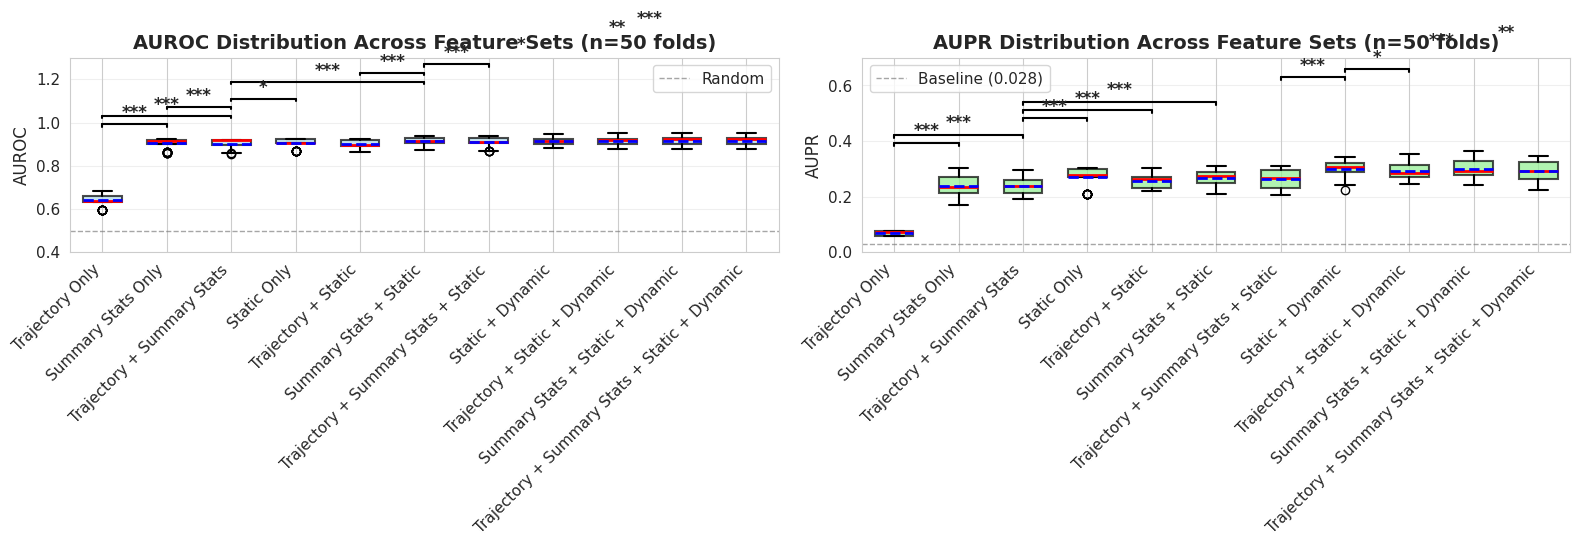


PAIRWISE STATISTICAL COMPARISONS (Wilcoxon Signed-Rank Test)
Comparison                                                   AUROC p      Sig   AUPR p       Sig  
--------------------------------------------------------------------------------
Trajectory Only vs Summary Stats Only                        0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.2632        +0.1688
Trajectory Only vs Trajectory + Summary Stats                0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.2607        +0.1699
Summary Stats Only vs Trajectory + Summary Stats             0.0005       ***   0.7304            
  Effect size (Δ):                                           -0.0025        +0.0011
Trajectory + Summary Stats vs Static Only                    0.0186       *     0.0000       ***  
  Effect size (Δ):                                           +0.0028        +0.0327
Trajectory + Summary Stats

In [24]:
# Boxplot visualization with statistical significance testing
pairs_to_compare = [
    (0, 1),  # Trajectory vs Summary
    (0, 2),  # Trajectory vs Trajectory + Summary
    (1, 2),  # Summary vs Trajectory + Summary
    (2, 3),  # Trajectory + Summary vs Static Only
    (2, 4),  # Trajectory + Summary vs Trajectory + Static
    (2, 5),  # Trajectory + Summary vs Summary + Static
    (4, 5),  # Trajectory + Static vs Summary + Static

    (5, 6),  # Summary + Static vs Trajectory + Summary + Static
    (6, 7),  # Trajectory + Summary + Static vs Static + Dynamic
    (7, 8),  # Static + Dynamic vs Trajectory + Static + Dynamic
    (7, 9),  # Static + Dynamic vs Summary + Static + Dynamic
    (8, 9),  # Trajectory + Static + Dynamic vs Summary + Static + Dynamic
    (9, 10), # Summary + Static + Dynamic vs Trajectory + Summary + Static + Dynamic
]

# Use shared utility function for boxplots with significance testing
fig, (ax1, ax2) = plot_boxplots_with_stats(
    comparison_results=comparison_results,
    outcome_df=prediction_clean,
    target_col='target_aki_stage3',
    pairs_to_compare=pairs_to_compare,
    n_folds_total=n_folds_total,
    roc_ylim=(0.4, 1.3),
    ap_ylim=(0.0, 0.7)
)
plt.savefig('../../results/hirid/aki/model_comparison_boxplots_significance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/hirid/aki/model_comparison_boxplots_significance.png")
plt.show()

# Print detailed statistical comparisons using shared utility
print_statistical_comparisons(
    comparison_results=comparison_results,
    pairs_to_compare=pairs_to_compare
)


📊 Performance Summary:
                                        Model       ROC-AUC Avg Precision
                              Trajectory Only 0.642 ± 0.029 0.069 ± 0.008
                           Summary Stats Only 0.905 ± 0.022 0.238 ± 0.040
                   Trajectory + Summary Stats 0.902 ± 0.023 0.239 ± 0.031
                                  Static Only 0.905 ± 0.019 0.272 ± 0.034
                          Trajectory + Static 0.899 ± 0.021 0.258 ± 0.029
                       Summary Stats + Static 0.912 ± 0.021 0.266 ± 0.029
          Trajectory + Summary Stats + Static 0.910 ± 0.022 0.264 ± 0.033
                             Static + Dynamic 0.914 ± 0.021 0.298 ± 0.029
                Trajectory + Static + Dynamic 0.914 ± 0.022 0.291 ± 0.028
             Summary Stats + Static + Dynamic 0.916 ± 0.023 0.299 ± 0.033
Trajectory + Summary Stats + Static + Dynamic 0.916 ± 0.023 0.292 ± 0.034

✓ Saved: results/hirid/aki/model_comparison_curves.png


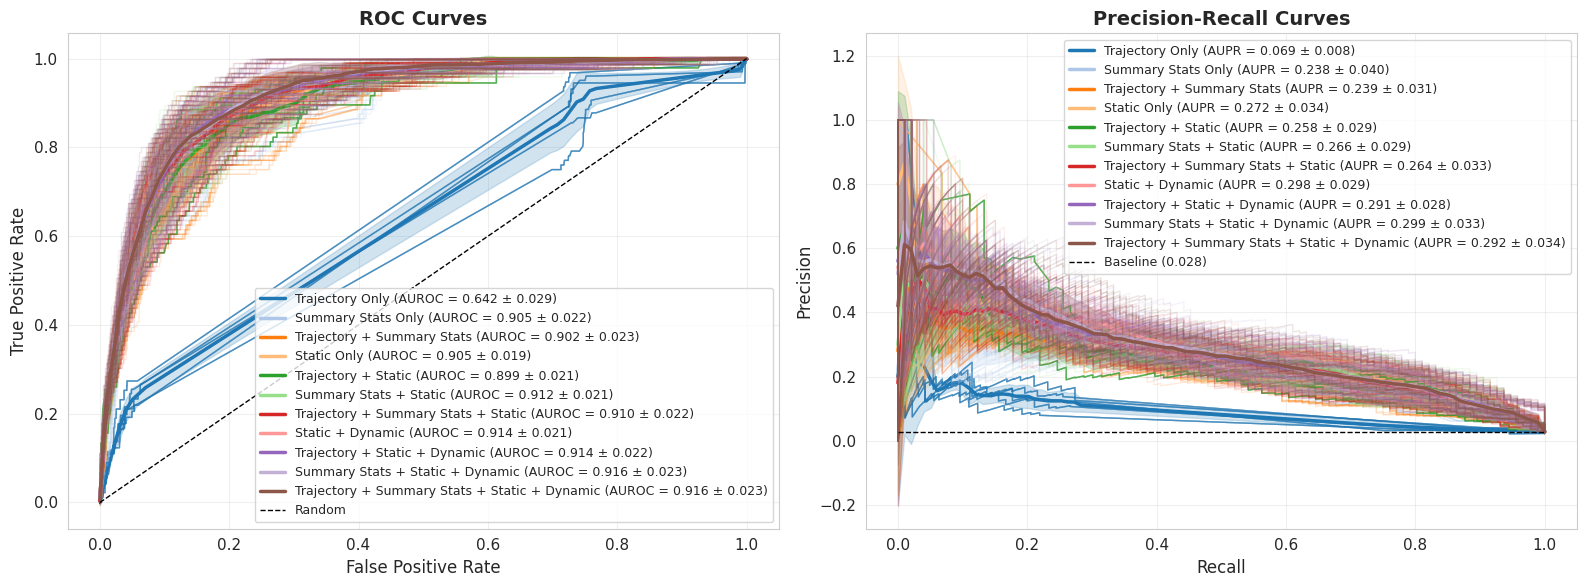

In [25]:
# Performance comparison table
summary_df = pd.DataFrame([
    {
        'Model': name,
        'ROC-AUC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
        'Avg Precision': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}"
    }
    for name, metrics in comparison_results.items()
])

print("\n📊 Performance Summary:")
print(summary_df.to_string(index=False))

# ROC & PR Curves - Using shared utility function
fig, (ax1, ax2) = plot_roc_pr_curves(
    comparison_results=comparison_results,
    outcome_df=prediction_clean,
    target_col='target_aki_stage3',
    color_scheme='tab20'
)
plt.savefig('../../results/hirid/aki/model_comparison_curves.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/hirid/aki/model_comparison_curves.png")
plt.show()